In [1]:
# 1. Imports
import os
import glob
import pandas as pd
import numpy as np
import pprint
from datetime import datetime, timedelta

import pyspark
import pyspark.sql.functions as F
from pyspark.sql.functions import col

import lightgbm as lgb
from sklearn.metrics import mean_squared_error
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

ModuleNotFoundError: No module named 'pyspark'

In [21]:
# 2. Initialize SparkSession (using your working approach)
spark = pyspark.sql.SparkSession.getActiveSession()
if spark is None:
    spark = pyspark.sql.SparkSession.builder \
        .appName("EnergyPrediction") \
        .master("local[*]") \
        .config("spark.driver.memory", "4g") \
        .getOrCreate()

spark.sparkContext.setLogLevel("WARN")

print("✓ Spark session initialized")
print(f"PySpark Version: {spark.version}")

✓ Spark session initialized
PySpark Version: 3.5.5


25/06/12 16:18:55 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [95]:
# 3. Configuration Setup
print("="*60)
print("ENERGY PREDICTION - CONFIGURATION SETUP")
print("="*60)

# Base configuration - easy to modify for different experiments
start_date_str = "2016-01-01"
end_date_str = "2016-02-06"  # Based on our 37 days of data
train_start_timestamp = 20160101
train_end_timestamp = 20160125
valid_start_timestamp = 20160126
valid_end_timestamp = 20160206

config = {}

# Data configuration
config["data_path"] = "/app/data/gold_table_v5/meters"
config["start_date_str"] = start_date_str
config["end_date_str"] = end_date_str
config["start_date"] = datetime.strptime(start_date_str, "%Y-%m-%d")
config["end_date"] = datetime.strptime(end_date_str, "%Y-%m-%d")

# Training configuration
config["meters_to_train"] = [0,1,2,3,4,5,6,7]  # Can be modified to include [0,1,2,3,4,5,6,7]
config["sites_to_exclude"] = []  
config["train_start"] = train_start_timestamp
config["train_end"] = train_end_timestamp
config["valid_start"] = valid_start_timestamp
config["valid_end"] = valid_end_timestamp

# Model configuration
config["random_seed"] = 42
config["learning_rate"] = 0.05
config["num_leaves"] = 31
config["n_estimators"] = 500
config["lgb_params"] = {
    'learning_rate': config["learning_rate"],
    'num_leaves': config["num_leaves"],
    'colsample_bytree': 0.8,
    'subsample_freq': 1,
    'subsample': 0.8,
}

# Output configuration
config["model_save_path"] = "../models"
config["experiment_name"] = f"energy_pred_{start_date_str}_to_{end_date_str}"

print("Configuration:")
print("="*40)
pprint.pprint(config)


ENERGY PREDICTION - CONFIGURATION SETUP
Configuration:
{'data_path': '/app/data/gold_table_v5/meters',
 'end_date': datetime.datetime(2016, 2, 6, 0, 0),
 'end_date_str': '2016-02-06',
 'experiment_name': 'energy_pred_2016-01-01_to_2016-02-06',
 'learning_rate': 0.05,
 'lgb_params': {'colsample_bytree': 0.8,
                'learning_rate': 0.05,
                'num_leaves': 31,
                'subsample': 0.8,
                'subsample_freq': 1},
 'meters_to_train': [0, 1, 2, 3, 4, 5, 6, 7],
 'model_save_path': '../models',
 'n_estimators': 500,
 'num_leaves': 31,
 'random_seed': 42,
 'sites_to_exclude': [],
 'start_date': datetime.datetime(2016, 1, 1, 0, 0),
 'start_date_str': '2016-01-01',
 'train_end': 20160125,
 'train_start': 20160101,
 'valid_end': 20160206,
 'valid_start': 20160126}


In [96]:
# 4. Create Directories
# Create directories if they don't exist
os.makedirs(config["model_save_path"], exist_ok=True)
print(f"✓ Model save directory created: {config['model_save_path']}")

✓ Model save directory created: ../models


In [97]:
# 4a: Load Data
folder_path = config["data_path"]
files_list = [folder_path + "/" + f for f in os.listdir(folder_path) if f.endswith('.parquet')]
meters_sdf = spark.read.parquet(*files_list)

# Cache the main dataset - will be used multiple times
meters_sdf.cache()

print("row_count:", meters_sdf.count())
meters_sdf.show(5)


25/06/12 17:46:01 WARN CacheManager: Asked to cache already cached data.        


row_count: 1927307
+-----------+-----+-------+-------------------+-------------+-----------+-------+----------+-----------+--------------+--------------+--------------+-------------+---------+-------------+---+----+-------+---------+---------------------+--------------+-----------------+----------------+------------------+--------------------+------------------+--------------------+---------------------+--------------------+
|building_id|meter|site_id|          timestamp|meter_reading|primary_use|    sqm|year_built|floor_count|airTemperature|dewTemperature|seaLvlPressure|windDirection|windSpeed|cloudCoverage|day|hour|weekday|IsHoliday|is_day_off_or_holiday|year_built_cat|building_meter_95|building_meter_5| frac_building_day|    frac_primary_day|frac_building_hour|   frac_primary_hour|frac_building_weekday|frac_primary_weekday|
+-----------+-----+-------+-------------------+-------------+-----------+-------+----------+-----------+--------------+--------------+--------------+------------

In [100]:
# 5. Filter Data by Meter
filtered_sdf = meters_sdf.filter(col("meter").isin(config["meters_to_train"]))
print("filtered row_count:", filtered_sdf.count())
filtered_sdf.groupBy("meter").count().orderBy("meter").show()

# Cell 6: Create timestamp integer for splitting
# Add timestamp as integer for easier filtering (following original code pattern)
data_sdf = filtered_sdf.withColumn(
    "timestamp_int", 
    F.year("timestamp") * 10000 + F.month("timestamp") * 100 + F.dayofmonth("timestamp")
)

# Cache data_sdf since it will be used for both train and valid splits
data_sdf.cache()

print("timestamp_int created")
data_sdf.select("timestamp", "timestamp_int").distinct().orderBy("timestamp_int").show(5)


filtered row_count: 1927307


+-----+-------+
|meter|  count|
+-----+-------+
|    0|1086238|
|    1| 300583|
|    2| 260749|
|    3| 108729|
|    4| 105756|
|    5|   6223|
|    6|   2526|
|    7|  56503|
+-----+-------+

timestamp_int created


[Stage 106:=============================================>      (172 + 16) / 198]

+-------------------+-------------+
|          timestamp|timestamp_int|
+-------------------+-------------+
|2016-01-01 21:00:00|     20160101|
|2016-01-01 00:00:00|     20160101|
|2016-01-01 16:00:00|     20160101|
|2016-01-01 09:00:00|     20160101|
|2016-01-01 11:00:00|     20160101|
+-------------------+-------------+
only showing top 5 rows



In [101]:
# 6. Create timestamp integer for splitting
# Add timestamp as integer for easier filtering (following original code pattern)
data_sdf = filtered_sdf.withColumn(
    "timestamp_int", 
    F.year("timestamp") * 10000 + F.month("timestamp") * 100 + F.dayofmonth("timestamp")
)

print("timestamp_int created")
data_sdf.select("timestamp", "timestamp_int").distinct().orderBy("timestamp_int").show(5)


timestamp_int created
+-------------------+-------------+
|          timestamp|timestamp_int|
+-------------------+-------------+
|2016-01-01 21:00:00|     20160101|
|2016-01-01 00:00:00|     20160101|
|2016-01-01 16:00:00|     20160101|
|2016-01-01 09:00:00|     20160101|
|2016-01-01 11:00:00|     20160101|
+-------------------+-------------+
only showing top 5 rows



In [102]:
# 7. Split data into train and validation
# Filter by sites (exclude site_id in config)
if config["sites_to_exclude"]:
    data_sdf = data_sdf.filter(~col("site_id").isin(config["sites_to_exclude"]))
    print(f"Excluded sites {config['sites_to_exclude']}, remaining records:", data_sdf.count())

# Split into train and validation sets
train_sdf = data_sdf.filter(
    (col("timestamp_int") >= config["train_start"]) & 
    (col("timestamp_int") < config["train_end"])
)

valid_sdf = data_sdf.filter(
    (col("timestamp_int") >= config["valid_start"]) & 
    (col("timestamp_int") < config["valid_end"])
)

# Cache train and valid sets since they'll be converted to pandas
train_sdf.cache()
valid_sdf.cache()

print("train records:", train_sdf.count())
print("valid records:", valid_sdf.count())


train records: 1247445
valid records: 576414


In [103]:
# 8. Convert to Pandas for modeling
print("Converting to Pandas...")
train_pdf = train_sdf.toPandas()
valid_pdf = valid_sdf.toPandas()

print(f"train_pdf shape: {train_pdf.shape}")
print(f"valid_pdf shape: {valid_pdf.shape}")


Converting to Pandas...
train_pdf shape: (1247445, 30)
valid_pdf shape: (576414, 30)


In [168]:
# 9. Data Preparation (Following Original Logic)
print("="*60)
print("DATA PREPARATION - FOLLOWING ORIGINAL STRATEGY")
print("="*60)

# Prepare features and target variable
feature_columns = [col for col in train_pdf.columns if col not in ['meter_reading', 'timestamp', 'timestamp_int']]
target_fe = train_pdf['meter_reading'].copy()

# Apply log transformation to the target (as per original code)
train_pdf['meter_reading_log'] = np.log1p(train_pdf['meter_reading'])
valid_pdf['meter_reading_log'] = np.log1p(valid_pdf['meter_reading'])

X_train = train_pdf.drop(['meter_reading', 'meter_reading_log'], axis=1)
X_valid = valid_pdf.drop(['meter_reading', 'meter_reading_log'], axis=1)
y_train = train_pdf['meter_reading_log']
y_valid = valid_pdf['meter_reading_log']

print(f"Features: {len(feature_columns)} columns")
print(f"Train shape: {X_train.shape}, Valid shape: {X_valid.shape}")

# Check data types
print(f"\nData types in X_train:")
print(X_train.dtypes.value_counts())

# Check for datetime columns
datetime_cols = X_train.select_dtypes(include=['datetime64']).columns
if len(datetime_cols) > 0:
    print(f"\nWarning: Found datetime columns: {datetime_cols.tolist()}")

# Check for categorical features
categorical_cols = ['building_id', 'site_id', 'primary_use', 'hour', 'day', 'weekday', 'year_built_cat']
available_categorical = [col for col in categorical_cols if col in X_train.columns]
print(f"\nAvailable categorical features: {available_categorical}")

# Check for missing values
missing_train = X_train.isnull().sum().sum()
missing_valid = X_valid.isnull().sum().sum()
print(f"\nMissing values - Train: {missing_train}, Valid: {missing_valid}")

if missing_train > 0 or missing_valid > 0:
    print("Columns with missing values:")
    missing_cols_train = X_train.columns[X_train.isnull().any()].tolist()
    missing_cols_valid = X_valid.columns[X_valid.isnull().any()].tolist()
    print(f"Train: {missing_cols_train}")
    print(f"Valid: {missing_cols_valid}")

DATA PREPARATION - FOLLOWING ORIGINAL STRATEGY
Features: 28 columns
Train shape: (1247445, 29), Valid shape: (576414, 29)

Data types in X_train:
int32             12
float64           12
float32            3
datetime64[ns]     1
object             1
Name: count, dtype: int64


Available categorical features: ['building_id', 'site_id', 'primary_use', 'hour', 'day', 'weekday', 'year_built_cat']

Missing values - Train: 0, Valid: 0


In [169]:
# 10. Training Function Implementation

def meter_fit_original(meter, X_train, X_valid, y_train, y_valid, n_estimators=500, verbose=100, random_state=42, **params):
    """
    Creates individual validation sets for each building_id.
    """
    print(f"\n{'='*50}")
    print(f"TRAINING METER {meter} - ORIGINAL STRATEGY")
    print(f"{'='*50}")
    
    model = lgb.LGBMRegressor(
        random_state=random_state, 
        n_estimators=n_estimators, 
        n_jobs=-1, 
        metric='rmse', 
        **params
    )

    # Filter data for the current meter
    X_train_m = X_train.query('meter == {}'.format(meter)).copy()
    X_valid_m = X_valid.query('meter == {}'.format(meter)).copy()
    y_train_m = y_train[X_train_m.index]
    y_valid_m = y_valid[X_valid_m.index]

    # Drop unnecessary columns (datetime and identifier columns)
    columns_to_drop = ['meter', 'timestamp', 'timestamp_int']
    for col in columns_to_drop:
        if col in X_train_m.columns:
            X_train_m = X_train_m.drop(col, axis=1)
        if col in X_valid_m.columns:
            X_valid_m = X_valid_m.drop(col, axis=1)

    print(f"Meter {meter} - Train: {len(X_train_m)}, Valid: {len(X_valid_m)}")
    print(f"Features: {X_train_m.columns.tolist()}")
    
    if len(X_train_m) == 0 or len(X_valid_m) == 0:
        print(f"No data for meter {meter}")
        return None

    # Check and remove datetime columns if any
    datetime_cols = X_train_m.select_dtypes(include=['datetime64']).columns
    if len(datetime_cols) > 0:
        print(f"Warning: Found datetime columns: {datetime_cols.tolist()}")
        X_train_m = X_train_m.drop(datetime_cols, axis=1)
        X_valid_m = X_valid_m.drop(datetime_cols, axis=1)

    # Set categorical features
    categorical_features = ['building_id', 'site_id', 'primary_use', 'hour', 'day', 'weekday', 'year_built_cat']
    for col in categorical_features:
        if col in X_train_m.columns:
            X_train_m[col] = X_train_m[col].astype('category')
            X_valid_m[col] = X_valid_m[col].astype('category')

    # Create validation sets for each building_id
    g = X_valid_m.groupby('building_id')
    eval_names = ['train', 'valid']
    eval_set = [(X_train_m, y_train_m), (X_valid_m, y_valid_m)]
    
    print(f"Creating individual validation sets for {len(X_valid_m['building_id'].unique())} buildings...")
    
    # Append individual building validation sets
    for i in sorted(X_valid_m['building_id'].unique()):
        set_evalX = g.get_group(i)
        eval_set.append((set_evalX, y_valid_m.loc[set_evalX.index]))
        eval_names.append(i)  # Use building_id as eval_name

    print(f"Total eval sets: {len(eval_set)} (train + valid + {len(eval_names)-2} buildings)")

    # Train model
    model.fit(
        X_train_m, y_train_m,
        eval_set=eval_set,
        eval_names=eval_names,
        callbacks=[lgb.log_evaluation(verbose)]
    )

    return model


def meter_fit_all_original(meter, X_train_cleaned, y_train_cleaned, n_estimators, random_state=42, **params):
    """
    Train the final model using the fully cleaned dataset.
    """
    print(f"\n{'='*50}")
    print(f"FINAL TRAINING METER {meter} - CLEANED DATA")
    print(f"{'='*50}")
    
    X_train_m = X_train_cleaned.query('meter == {}'.format(meter)).copy()
    y_train_m = y_train_cleaned[X_train_m.index]

    # Drop unnecessary columns
    columns_to_drop = ['meter', 'timestamp', 'timestamp_int']
    for col in columns_to_drop:
        if col in X_train_m.columns:
            X_train_m = X_train_m.drop(col, axis=1)

    print(f"Meter {meter} - Final training samples: {len(X_train_m)}")
    
    if len(X_train_m) == 0:
        return None

    # Check and remove datetime columns if any
    datetime_cols = X_train_m.select_dtypes(include=['datetime64']).columns
    if len(datetime_cols) > 0:
        print(f"Warning: Found datetime columns: {datetime_cols.tolist()}")
        X_train_m = X_train_m.drop(datetime_cols, axis=1)

    # Set categorical features
    categorical_features = ['building_id', 'site_id', 'primary_use', 'hour', 'day', 'weekday', 'year_built_cat']
    for col in categorical_features:
        if col in X_train_m.columns:
            X_train_m[col] = X_train_m[col].astype('category')

    model = lgb.LGBMRegressor(
        random_state=random_state, 
        n_estimators=n_estimators, 
        n_jobs=-1, 
        metric='rmse', 
        **params
    )
    
    model.fit(
        X_train_m, y_train_m,
        eval_set=[(X_train_m, y_train_m)],
        callbacks=[lgb.log_evaluation(1000)]
    )
    
    return model


In [170]:
# 11. Stage 1 Training – Determine Optimal Iterations at Building Level
print("="*60)
print("STAGE 1: TRAINING WITH BUILDING-LEVEL VALIDATION")
print("="*60)

models = {}
lgb_params = config["lgb_params"]

# Train a model for each meter type
for meter in config["meters_to_train"]:
    print(f'\nMeter {meter} started at {datetime.now().strftime("%H:%M:%S")}')
    start_time = datetime.now()
    
    models[meter] = meter_fit_original(
        meter, X_train, X_valid, y_train, y_valid, 
        random_state=config["random_seed"], 
        n_estimators=config["n_estimators"], 
        verbose=1000,  # Reduce logging frequency
        **lgb_params
    )
    
    end_time = datetime.now()
    print(f'Meter {meter} training completed in {end_time - start_time}')

print("✓ Stage 1 training completed")


STAGE 1: TRAINING WITH BUILDING-LEVEL VALIDATION

Meter 0 started at 02:19:28

TRAINING METER 0 - ORIGINAL STRATEGY
Meter 0 - Train: 701767, Valid: 326932
Features: ['building_id', 'site_id', 'primary_use', 'sqm', 'year_built', 'floor_count', 'airTemperature', 'dewTemperature', 'seaLvlPressure', 'windDirection', 'windSpeed', 'cloudCoverage', 'day', 'hour', 'weekday', 'IsHoliday', 'is_day_off_or_holiday', 'year_built_cat', 'building_meter_95', 'building_meter_5', 'frac_building_day', 'frac_primary_day', 'frac_building_hour', 'frac_primary_hour', 'frac_building_weekday', 'frac_primary_weekday']
Creating individual validation sets for 1323 buildings...


/tmp/ipykernel_1977/38909317.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = X_valid_m.groupby('building_id')


Total eval sets: 1325 (train + valid + 1323 buildings)
Meter 0 training completed in 0:03:06.155183

Meter 1 started at 02:22:34

TRAINING METER 1 - ORIGINAL STRATEGY
Meter 1 - Train: 195499, Valid: 88931
Features: ['building_id', 'site_id', 'primary_use', 'sqm', 'year_built', 'floor_count', 'airTemperature', 'dewTemperature', 'seaLvlPressure', 'windDirection', 'windSpeed', 'cloudCoverage', 'day', 'hour', 'weekday', 'IsHoliday', 'is_day_off_or_holiday', 'year_built_cat', 'building_meter_95', 'building_meter_5', 'frac_building_day', 'frac_primary_day', 'frac_building_hour', 'frac_primary_hour', 'frac_building_weekday', 'frac_primary_weekday']
Creating individual validation sets for 383 buildings...


/tmp/ipykernel_1977/38909317.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = X_valid_m.groupby('building_id')


Total eval sets: 385 (train + valid + 383 buildings)
Meter 1 training completed in 0:00:58.110370

Meter 2 started at 02:23:32

TRAINING METER 2 - ORIGINAL STRATEGY
Meter 2 - Train: 169597, Valid: 76913
Features: ['building_id', 'site_id', 'primary_use', 'sqm', 'year_built', 'floor_count', 'airTemperature', 'dewTemperature', 'seaLvlPressure', 'windDirection', 'windSpeed', 'cloudCoverage', 'day', 'hour', 'weekday', 'IsHoliday', 'is_day_off_or_holiday', 'year_built_cat', 'building_meter_95', 'building_meter_5', 'frac_building_day', 'frac_primary_day', 'frac_building_hour', 'frac_primary_hour', 'frac_building_weekday', 'frac_primary_weekday']
Creating individual validation sets for 313 buildings...


...

Meter 5 training completed in 0:00:03.622483

Meter 6 started at 02:25:36

TRAINING METER 6 - ORIGINAL STRATEGY
Meter 6 - Train: 1579, Valid: 820
Features: ['building_id', 'site_id', 'primary_use', 'sqm', 'year_built', 'floor_count', 'airTemperature', 'dewTemperature', 'seaLvlPressure', 'windDirection', 'windSpeed', 'cloudCoverage', 'day', 'hour', 'weekday', 'IsHoliday', 'is_day_off_or_holiday', 'year_built_cat', 'building_meter_95', 'building_meter_5', 'frac_building_day', 'frac_primary_day', 'frac_building_hour', 'frac_primary_hour', 'frac_building_weekday', 'frac_primary_weekday']
Creating individual validation sets for 4 buildings...
Total eval sets: 6 (train + valid + 4 buildings)


/tmp/ipykernel_1977/38909317.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = X_valid_m.groupby('building_id')


Meter 6 training completed in 0:00:01.866355

Meter 7 started at 02:25:38

TRAINING METER 7 - ORIGINAL STRATEGY
Meter 7 - Train: 35378, Valid: 17808
Features: ['building_id', 'site_id', 'primary_use', 'sqm', 'year_built', 'floor_count', 'airTemperature', 'dewTemperature', 'seaLvlPressure', 'windDirection', 'windSpeed', 'cloudCoverage', 'day', 'hour', 'weekday', 'IsHoliday', 'is_day_off_or_holiday', 'year_built_cat', 'building_meter_95', 'building_meter_5', 'frac_building_day', 'frac_primary_day', 'frac_building_hour', 'frac_primary_hour', 'frac_building_weekday', 'frac_primary_weekday']
Creating individual validation sets for 113 buildings...
Total eval sets: 115 (train + valid + 113 buildings)


/tmp/ipykernel_1977/38909317.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  g = X_valid_m.groupby('building_id')


Meter 7 training completed in 0:00:12.323423
✓ Stage 1 training completed


In [171]:
# 12. Calculate the Optimal Iteration for Each Building
print("="*60)
print("CALCULATING OPTIMAL ITERATIONS PER BUILDING")
print("="*60)

best_iteration = {}
for meter in config["meters_to_train"]:
    if meter not in models or models[meter] is None:
        continue
        
    best_iteration[meter] = {}
    
    # Retrieve all building_ids from the validation set for this meter
    valid_buildings = sorted(X_valid.query('meter == {}'.format(meter))['building_id'].unique())
    
    print(f"Processing {len(valid_buildings)} buildings for meter {meter}...")
    
    for building_id in valid_buildings:
        try:
            # Get the RMSE history for this building from evals_result
            building_rmse = models[meter].evals_result_[building_id]['rmse']
            # Identify the iteration with the lowest RMSE
            optimal_iter = np.argmin(building_rmse) + 1
            # Set a minimum iteration threshold of 20
            best_iteration[meter][building_id] = max(20, optimal_iter)
        except KeyError:
            # If the building is not present in evals_result, assign a default value
            best_iteration[meter][building_id] = 200
    
    print(f"Meter {meter}: Optimal iterations calculated for {len(best_iteration[meter])} buildings")


CALCULATING OPTIMAL ITERATIONS PER BUILDING
Processing 1323 buildings for meter 0...
Meter 0: Optimal iterations calculated for 1323 buildings
Processing 383 buildings for meter 1...
Meter 1: Optimal iterations calculated for 383 buildings
Processing 313 buildings for meter 2...
Meter 2: Optimal iterations calculated for 313 buildings
Processing 155 buildings for meter 3...
Meter 3: Optimal iterations calculated for 155 buildings
Processing 161 buildings for meter 4...
Meter 4: Optimal iterations calculated for 161 buildings
Processing 19 buildings for meter 5...
Meter 5: Optimal iterations calculated for 19 buildings
Processing 4 buildings for meter 6...
Meter 6: Optimal iterations calculated for 4 buildings
Processing 113 buildings for meter 7...
Meter 7: Optimal iterations calculated for 113 buildings


In [172]:
# 13. Data Cleaning - Removing Low-Quality Buildings
print("="*60)
print("DATA CLEANING - REMOVING POOR QUALITY BUILDINGS")
print("="*60)

# Identify buildings to be removed (those with too few optimal iterations)
del_list = {meter: [] for meter in config["meters_to_train"]}

for meter in config["meters_to_train"]:
    if meter not in best_iteration:
        continue
        
    for building_id, iteration in best_iteration[meter].items():
        if iteration <= 20:
            # Mark buildings with too few iterations for removal
            del_list[meter].append(building_id)
        if iteration <= 100:
            # Enforce a minimum iteration count
            best_iteration[meter][building_id] = 100  

    print(f"Meter {meter}: Marked {len(del_list[meter])} buildings for removal")

# Create a cleaned version of the training data
new_train_fe = X_train.copy()
new_train_fe['meter_reading_log'] = y_train

# Remove data from low-quality buildings
for meter in config["meters_to_train"]:
    if del_list[meter]:
        # Remove early-stage data for specified meter-building pairs
        mask = ~((new_train_fe['meter'] == meter) & 
                 (new_train_fe['building_id'].isin(del_list[meter])) & 
                 (new_train_fe['timestamp_int'] < config["train_end"]))
        new_train_fe = new_train_fe[mask]

# Separate the cleaned target variable and drop it from the feature set
new_target = new_train_fe['meter_reading_log']
new_train_fe = new_train_fe.drop('meter_reading_log', axis=1)

print(f"Original training samples: {len(X_train)}")
print(f"Cleaned training samples: {len(new_train_fe)}")

# Assign a default iteration value for buildings without specific best_iteration records
for meter in config["meters_to_train"]:
    if meter in best_iteration:
        # get all building_id in train and valid set
        train_buildings = set(X_train.query('meter == {}'.format(meter))['building_id'].unique())
        valid_buildings = set(X_valid.query('meter == {}'.format(meter))['building_id'].unique())
        all_buildings = train_buildings.union(valid_buildings)
        
        print(f"Meter {meter}: Found {len(all_buildings)} unique buildings")
        
        for building_id in all_buildings:
            if building_id not in best_iteration[meter]:
                best_iteration[meter][building_id] = 200
        
        print(f"Meter {meter}: Set default iterations for {len(all_buildings) - len([b for b in all_buildings if b in best_iteration[meter]])} buildings")

DATA CLEANING - REMOVING POOR QUALITY BUILDINGS
Meter 0: Marked 87 buildings for removal
Meter 1: Marked 30 buildings for removal
Meter 2: Marked 9 buildings for removal
Meter 3: Marked 13 buildings for removal
Meter 4: Marked 31 buildings for removal
Meter 5: Marked 6 buildings for removal
Meter 6: Marked 0 buildings for removal
Meter 7: Marked 13 buildings for removal
Original training samples: 1247445
Cleaned training samples: 1171678
Meter 0: Found 1340 unique buildings
Meter 0: Set default iterations for 0 buildings
Meter 1: Found 483 unique buildings
Meter 1: Set default iterations for 0 buildings
Meter 2: Found 316 unique buildings
Meter 2: Set default iterations for 0 buildings
Meter 3: Found 157 unique buildings
Meter 3: Set default iterations for 0 buildings
Meter 4: Found 169 unique buildings
Meter 4: Set default iterations for 0 buildings
Meter 5: Found 32 unique buildings
Meter 5: Set default iterations for 0 buildings
Meter 6: Found 4 unique buildings
Meter 6: Set default

In [173]:
# 14. Stage 2 Training – Final Model Training on Cleaned Data
print("="*60)
print("STAGE 2: FINAL TRAINING ON CLEANED DATA")
print("="*60)

models_all = {}

for meter in config["meters_to_train"]:
    print(f'Final training for meter {meter} started at {datetime.now().strftime("%H:%M:%S")}')
    start_time = datetime.now()
    
    # Use 1.5x the original number of iterations for final training
    final_n_estimators = int(config["n_estimators"] * 1.5)
    
    models_all[meter] = meter_fit_all_original(
        meter, new_train_fe, new_target, 
        n_estimators=final_n_estimators,
        random_state=config["random_seed"], 
        **lgb_params
    )
    
    end_time = datetime.now()
    print(f'Meter {meter} final training completed in {end_time - start_time}')

print("✓ Stage 2 training completed")


STAGE 2: FINAL TRAINING ON CLEANED DATA
Final training for meter 0 started at 02:36:08

FINAL TRAINING METER 0 - CLEANED DATA
Meter 0 - Final training samples: 660603
Meter 0 final training completed in 0:00:41.898889
Final training for meter 1 started at 02:36:50

FINAL TRAINING METER 1 - CLEANED DATA
Meter 1 - Final training samples: 185100
Meter 1 final training completed in 0:00:14.613291
Final training for meter 2 started at 02:37:05

FINAL TRAINING METER 2 - CLEANED DATA
Meter 2 - Final training samples: 165648
Meter 2 final training completed in 0:00:19.244220
Final training for meter 3 started at 02:37:24

FINAL TRAINING METER 3 - CLEANED DATA
Meter 3 - Final training samples: 65735
Meter 3 final training completed in 0:00:14.364842
Final training for meter 4 started at 02:37:39

FINAL TRAINING METER 4 - CLEANED DATA
Meter 4 - Final training samples: 57851
Meter 4 final training completed in 0:00:04.968738
Final training for meter 5 started at 02:37:44

FINAL TRAINING METER 5 -

In [174]:
# 15. Saving Models and Training Results
print("="*60)
print("SAVING MODELS AND TRAINING RESULTS")
print("="*60)

# Save Stage 1 models (with building-level validation)
stage1_filename = f"{config['model_save_path']}/stage1_models_{config['experiment_name']}.pkl"
with open(stage1_filename, 'wb') as f:
    pickle.dump(models, f)
print(f"✓ Stage 1 models saved: {stage1_filename}")

# Save final models
stage2_filename = f"{config['model_save_path']}/final_models_{config['experiment_name']}.pkl"
with open(stage2_filename, 'wb') as f:
    pickle.dump(models_all, f)
print(f"✓ Final models saved: {stage2_filename}")

# Save optimal iterations (needed for prediction)
iterations_filename = f"{config['model_save_path']}/best_iterations_{config['experiment_name']}.pkl"
with open(iterations_filename, 'wb') as f:
    pickle.dump(best_iteration, f)
print(f"✓ Best iterations saved: {iterations_filename}")

# Save complete training package
complete_package = {
    'stage1_models': models,
    'final_models': models_all,
    'best_iterations': best_iteration,
    'deleted_buildings': del_list,
    'config': config,
    'experiment_info': {
        'experiment_name': config['experiment_name'],
        'trained_meters': config['meters_to_train'],
        'original_train_samples': len(X_train),
        'cleaned_train_samples': len(new_train_fe),
        'valid_samples': len(X_valid),
        'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }
}

package_filename = f"{config['model_save_path']}/{config['experiment_name']}_complete_original_strategy.pkl"
with open(package_filename, 'wb') as f:
    pickle.dump(complete_package, f)

print(f"✓ Complete package saved: {package_filename}")

SAVING MODELS AND TRAINING RESULTS
✓ Stage 1 models saved: ../models/stage1_models_energy_pred_2016-01-01_to_2016-02-06.pkl
✓ Final models saved: ../models/final_models_energy_pred_2016-01-01_to_2016-02-06.pkl
✓ Best iterations saved: ../models/best_iterations_energy_pred_2016-01-01_to_2016-02-06.pkl
✓ Complete package saved: ../models/energy_pred_2016-01-01_to_2016-02-06_complete_original_strategy.pkl


In [175]:
# 16. Training Summary
print("="*60)
print("TRAINING SUMMARY - ORIGINAL STRATEGY")
print("="*60)

print(f"Experiment: {config['experiment_name']}")
print(f"Strategy: Building-level validation with individual optimal iterations")
print(f"Trained meters: {config['meters_to_train']}")

print(f"\nData Statistics:")
print(f"  Original training samples: {len(X_train):,}")
print(f"  Cleaned training samples: {len(new_train_fe):,}")
print(f"  Validation samples: {len(X_valid):,}")

print(f"\nBuilding-level Analysis:")
for meter in config["meters_to_train"]:
    if meter in best_iteration:
        iterations = list(best_iteration[meter].values())
        print(f"  Meter {meter}:")
        print(f"    Buildings processed: {len(iterations)}")
        print(f"    Avg optimal iterations: {np.mean(iterations):.1f}")
        print(f"    Buildings removed: {len(del_list[meter])}")

print(f"\nSaved Files:")
print(f"  - Stage 1 models: {stage1_filename}")
print(f"  - Final models: {stage2_filename}")
print(f"  - Best iterations: {iterations_filename}")
print(f"  - Complete package: {package_filename}")

print(f"\n✓ Original strategy training completed successfully!")
print("="*60)


TRAINING SUMMARY - ORIGINAL STRATEGY
Experiment: energy_pred_2016-01-01_to_2016-02-06
Strategy: Building-level validation with individual optimal iterations
Trained meters: [0, 1, 2, 3, 4, 5, 6, 7]

Data Statistics:
  Original training samples: 1,247,445
  Cleaned training samples: 1,171,678
  Validation samples: 576,414

Building-level Analysis:
  Meter 0:
    Buildings processed: 1340
    Avg optimal iterations: 266.1
    Buildings removed: 87
  Meter 1:
    Buildings processed: 483
    Avg optimal iterations: 242.4
    Buildings removed: 30
  Meter 2:
    Buildings processed: 316
    Avg optimal iterations: 346.2
    Buildings removed: 9
  Meter 3:
    Buildings processed: 157
    Avg optimal iterations: 266.9
    Buildings removed: 13
  Meter 4:
    Buildings processed: 169
    Avg optimal iterations: 307.9
    Buildings removed: 31
  Meter 5:
    Buildings processed: 32
    Avg optimal iterations: 189.4
    Buildings removed: 6
  Meter 6:
    Buildings processed: 4
    Avg optimal

In [180]:
# 17. =========  Single-Building Prediction  =========
import pickle, numpy as np, pandas as pd
from datetime import datetime

# 1) Load the complete training package -----------------------------------
package_path = f"{config['model_save_path']}/{config['experiment_name']}_complete_original_strategy.pkl"
with open(package_path, "rb") as f:
    package = pickle.load(f)

final_models     = package["final_models"]       # Stage-2 trained models
best_iterations  = package["best_iterations"]    # Best iterations per building
cfg              = package["config"]             # Config used during model saving

# 2) Choose a specific building and meter --------------------------------
meter_to_pred       = 0      # ← Change to the meter you want to predict
building_id_to_pred = 603    # ← Change to the building_id you want to predict

# 3) Prepare the data to be predicted (example using existing Spark DataFrame) -------------
test_sdf = data_sdf.filter(
    (col("meter") == meter_to_pred) &
    (col("building_id") == building_id_to_pred)
)

test_pdf = test_sdf.toPandas()
if test_pdf.empty:
    raise ValueError(" Cannot find data for the specified building/meter. Please check building_id and meter.")

# Use the same set of features as in training
test_pdf['meter_reading_log'] = np.log1p(test_pdf['meter_reading'])
X_test = test_pdf.drop(['meter_reading', 'meter_reading_log'], axis=1)

# — Remove unnecessary columns
for c in ['meter', 'timestamp', 'timestamp_int']:
    if c in X_test.columns:
        X_test = X_test.drop(c, axis=1)

# — Convert categorical columns to category dtype
cat_cols = ['building_id', 'site_id', 'primary_use', 'hour', 'day', 'weekday', 'year_built_cat']
for c in cat_cols:
    if c in X_test.columns:
        X_test[c] = X_test[c].astype('category')

# — Ensure the feature order matches training (using saved feature names from the model)
feature_order = final_models[meter_to_pred].booster_.feature_name()
X_test = X_test[feature_order]

# 4) Make Prediction -----------------------------------------------------
model    = final_models[meter_to_pred]
num_iter = best_iterations[meter_to_pred].get(building_id_to_pred, model.best_iteration_)

y_pred_log = model.predict(X_test, num_iteration=num_iter)
y_pred = np.expm1(y_pred_log)                       # Reverse log1p transformation
y_pred = np.clip(y_pred, a_min=0, a_max=None)       # Clip negative values to 0

test_pdf["pred_meter_reading"] = y_pred

# 5) Display results and simple evaluation -------------------------------
print(f"\n Prediction Results (building {building_id_to_pred}, meter {meter_to_pred}) - First 10 rows:")
display_cols = ["timestamp", "meter_reading", "pred_meter_reading"]
print(test_pdf[display_cols].head(10))
print(f"best iteration: ", num_iter)
rmse = np.sqrt(((test_pdf["meter_reading"] - test_pdf["pred_meter_reading"]) ** 2).mean())
print(f"\n RMSE = {rmse:.4f}")



 Prediction Results (building 603, meter 0) - First 10 rows:
            timestamp  meter_reading  pred_meter_reading
0 2016-02-05 00:00:00       1.050000           27.192054
1 2016-01-01 04:00:00      22.049999           25.023371
2 2016-01-02 12:00:00      22.820000           24.394294
3 2016-01-02 16:00:00      22.840000           23.408545
4 2016-01-02 23:00:00      21.559999           24.225651
5 2016-01-01 05:00:00      22.290001           24.310746
6 2016-01-01 09:00:00      23.080000           23.455908
7 2016-01-12 04:00:00      57.560001           40.873908
8 2016-01-12 19:00:00      29.080000           26.773212
9 2016-01-26 12:00:00      42.759998           35.231128
best iteration:  479

 RMSE = 12.4978


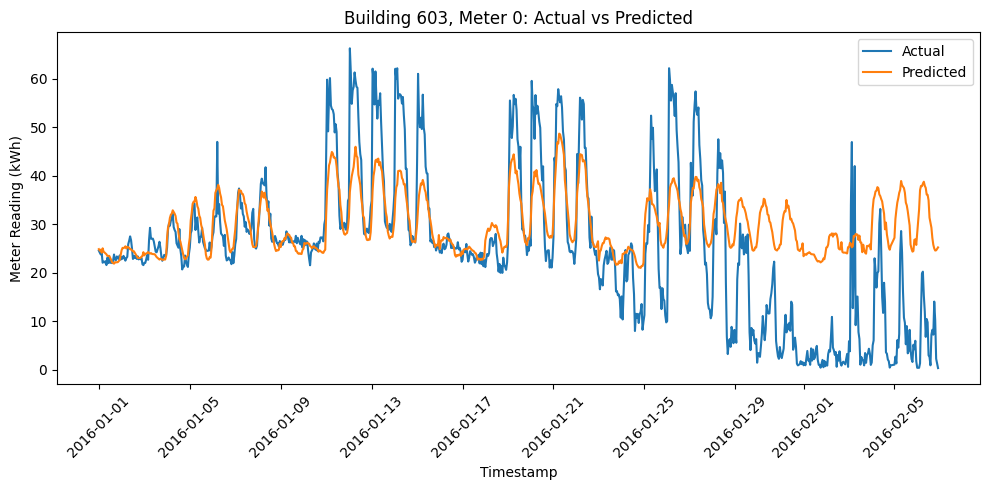

In [181]:
# 18. Ensure the prediction result DataFrame exists ────────────────────────
try:
    plot_df = test_pdf.copy()
except NameError:
    raise RuntimeError("Please run the prediction cell first to generate the 'test_pdf' DataFrame before executing this cell.")

# Sort the data to ensure timestamps are in order
plot_df = plot_df.sort_values("timestamp")

# ── 2. Plot: Actual vs Predicted ─────────────────────────────────────────────
plt.figure(figsize=(10, 5))

plt.plot(plot_df["timestamp"], plot_df["meter_reading"], label="Actual")
plt.plot(plot_df["timestamp"], plot_df["pred_meter_reading"], label="Predicted")

plt.xlabel("Timestamp")
plt.ylabel("Meter Reading (kWh)")
plt.title(f"Building {building_id_to_pred}, Meter {meter_to_pred}: Actual vs Predicted")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
